# `Exploratory Data Analysis of Student Performance Dataset`

### Student Performance Indicator
* Understanding the problem Statement
* Data Collection
* Data checks to Perform
* Exploratory Data Analysis
* Data Preprocessing 
* Model Training
* Choose Best Model

### `1-Problem Statement`
* The project understand how Student Performance is affected by Other Variable such as `Gender`,`Ethnicity`, `Parental level of Eduction` , `Lunch and Test Preparation Course`

### `2-Data Collection`
* Data Source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The data consists of `8 columns` and `1000 rows`

#### 2.1 Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

1- Reading the data 


In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

Showing top 5 records

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
## checking shape of dataset
df.shape

(1000, 8)

#### 2.2 Data Information
* gender : sex of students -> (Male/female)
* race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)

* parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)

* lunch : having lunch before test (standard or free/reduced)

* test preparation course : complete or not complete before test 
* math score
* reading score
* writing score

### 3. Data Checks to Perform
* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column 
* Check statistics of data set
* Check various categories present in the different categorical column

#### 3.1 Check Missing Values

In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Observation

#### `There are no missing values in the entire dataset`

### Checking Duplicates

In [7]:
df.duplicated().sum()

0

### `There is no duplicated values`

### 3.3 Check Data Types

In [8]:
df.info() ## check null and dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### `Five column have type object and three have integer`

### 3.4 Checking the Number of unique values of each column

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### `These are the unique values in each columns`

### 3.5 Check statistics of dataset

In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### `These are the descriptive Statistics of dataset`

### `Insights`
* From the above description of numerical data, all means are very close to each other- between 66 and 68.05;
* All standard deviation are also close - between 14.5 and 15.19; 
While there is a minimum score 0 for math , for writing minimum is much higher =10 and for reading myet higher=17

### 3.7 Exploring Data

In [12]:
print('Categories in gender variable: ',end="")
print(df['gender'].unique())

print('Categories in `race/ethnicity` variable: ',end="")
print(df['race/ethnicity'].unique())

print('Categories in parental level of education variable: ',end="")
print(df['parental level of education'].unique())

print('Categories in `lunch` variable: ',end="")
print(df['lunch'].unique())

print('Categories in `test preparation course` variable: ',end="")
print(df['test preparation course'].unique())

Categories in gender variable: ['female' 'male']
Categories in `race/ethnicity` variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental level of education variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in `lunch` variable: ['standard' 'free/reduced']
Categories in `test preparation course` variable: ['none' 'completed']


In [16]:
numerical_features = [col for col in df.columns if df[col].dtype!='O']
categorical_features = [col for col in df.columns if df[col].dtype=='O']

print('We have {} Numerical Features: {} '.format(len(numerical_features),numerical_features))
print('We have {} Categorical Features : {} '.format(len(categorical_features),categorical_features))

We have 3 Numerical Features: ['math score', 'reading score', 'writing score'] 
We have 5 Categorical Features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'] 


In [19]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


# `Feature Engineering`
### 3.8 Adding columns for "Total Score" and "Average"

In [17]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

df['average'] = df['total_score']/3

## Now this "total score" will be my dependent feature

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full = df[df['reading score']==100]['average'].count()
writing_full = df[df['writing score']==100]['average'].count()
math_full = df[df['math score']==100]['average'].count()

print(f"Number of Students with full marks in Maths: {math_full}")
print(f"Number of Students with full marks in writing: {math_full}")
print(f"Number of Students with full marks in reading: {reading_full}")

Number of Students with full marks in Maths: 7
Number of Students with full marks in writing: 7
Number of Students with full marks in reading: 17


## `Counting the Number of Student having Reading, Writing and Math Score less or equal to 20`

In [29]:
reading_less_20 = df[df['reading score']<=20]['average'].count()
writing_less_20 = df[df['writing score']<=20]['average'].count()
math_less_20 = df[df['math score']<=20]['average'].count()


print(f"Number of Students having Reading Score less than or Equal to tweenty are: {reading_less_20}")
print(f"Number of Students having Writing Score less than or Equal to tweenty are: {writing_less_20}")
print(f"Number of Students having Math Score less than or Equal to tweenty are: {math_less_20}")

Number of Students having Reading Score less than or Equal to tweenty are: 1
Number of Students having Writing Score less than or Equal to tweenty are: 3
Number of Students having Math Score less than or Equal to tweenty are: 4


### `Insights`
* From the above values we get students have performed the worst in maths
* Best performance is in reading section

# 4. Exploring Data ( Visualization )
## 4.1 Visualize average score distribution to make some conclusion.

### 4.1.1 `Histogram & KDE`


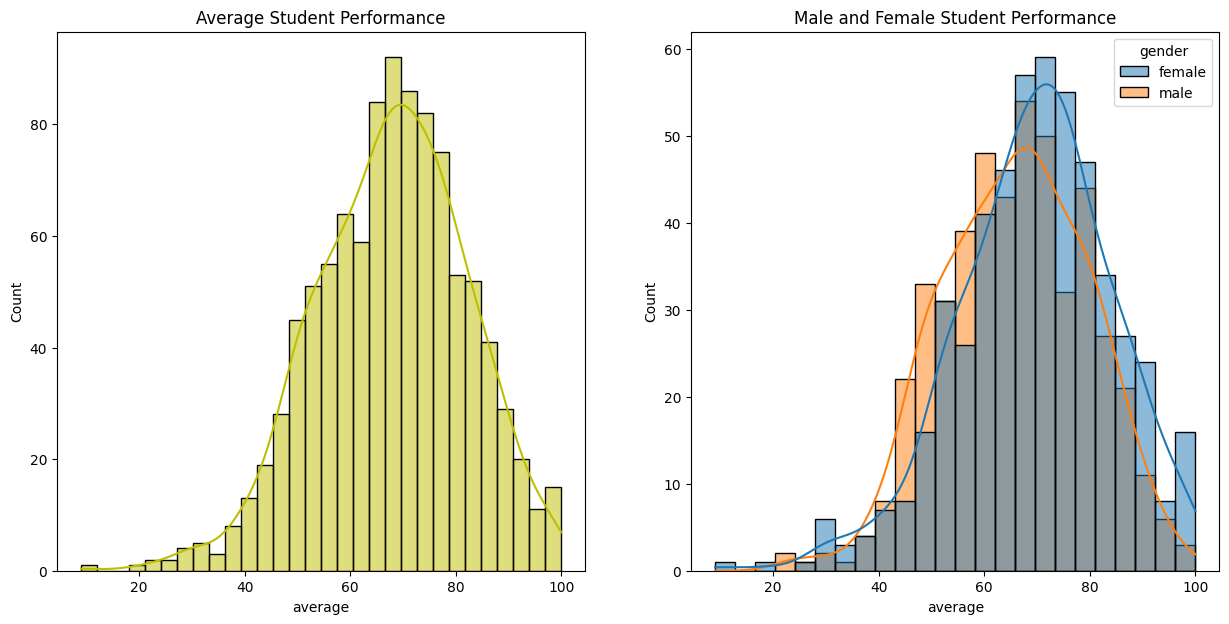

In [51]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,color='y',kde=True)
plt.title('Average Student Performance')

plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.title('Male and Female Student Performance')
plt.show()

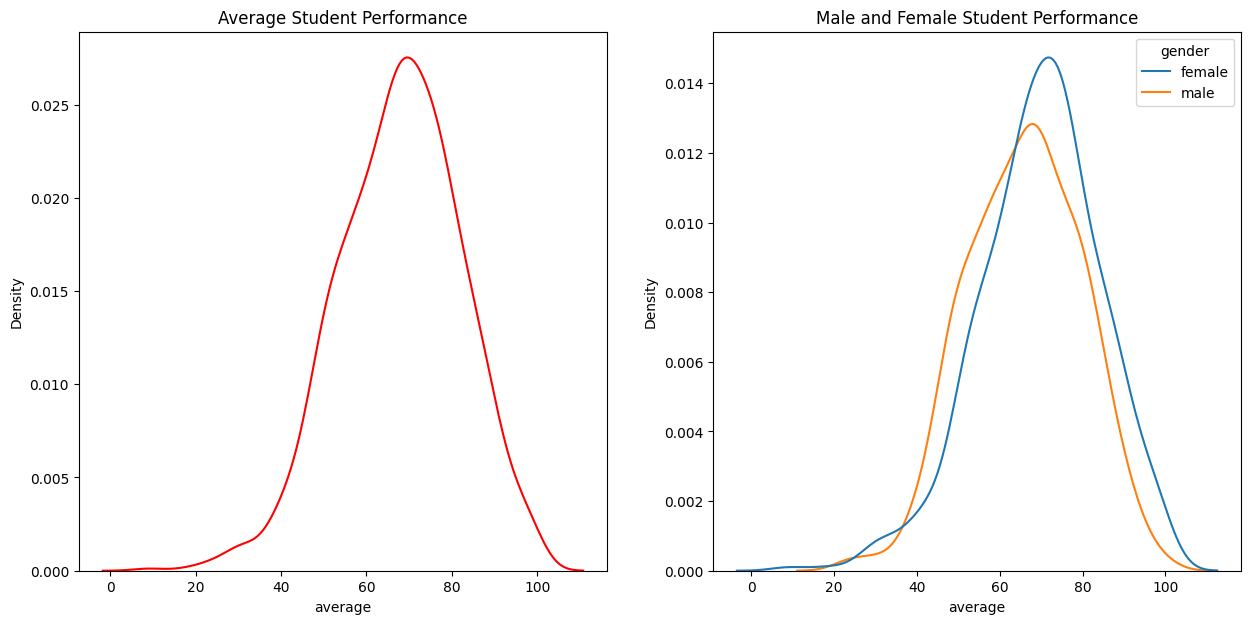

In [50]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.kdeplot(data=df,x='average',color='r')
plt.title('Average Student Performance')

plt.subplot(122)
sns.kdeplot(data=df,x='average',hue='gender')
plt.title('Male and Female Student Performance')
plt.show()

### `Insights`
* `Female student` tends to perform beter than `male student`

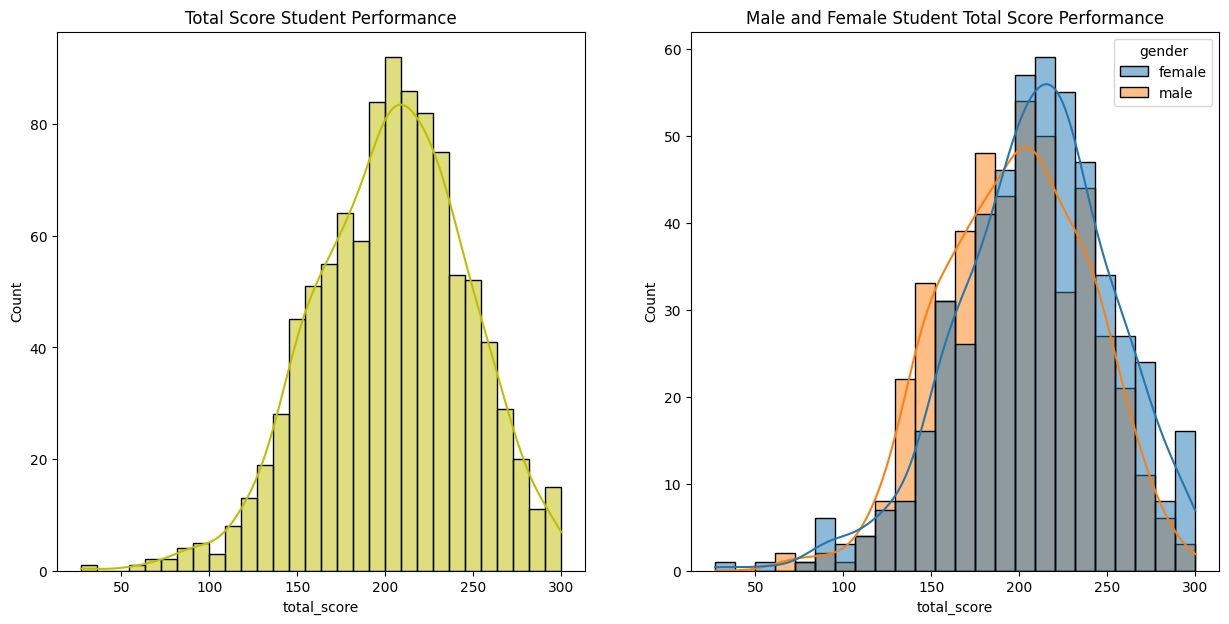

In [57]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,color='y',kde=True)
plt.title('Total Score Student Performance')

plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.title('Male and Female Student Total Score Performance')
plt.show()

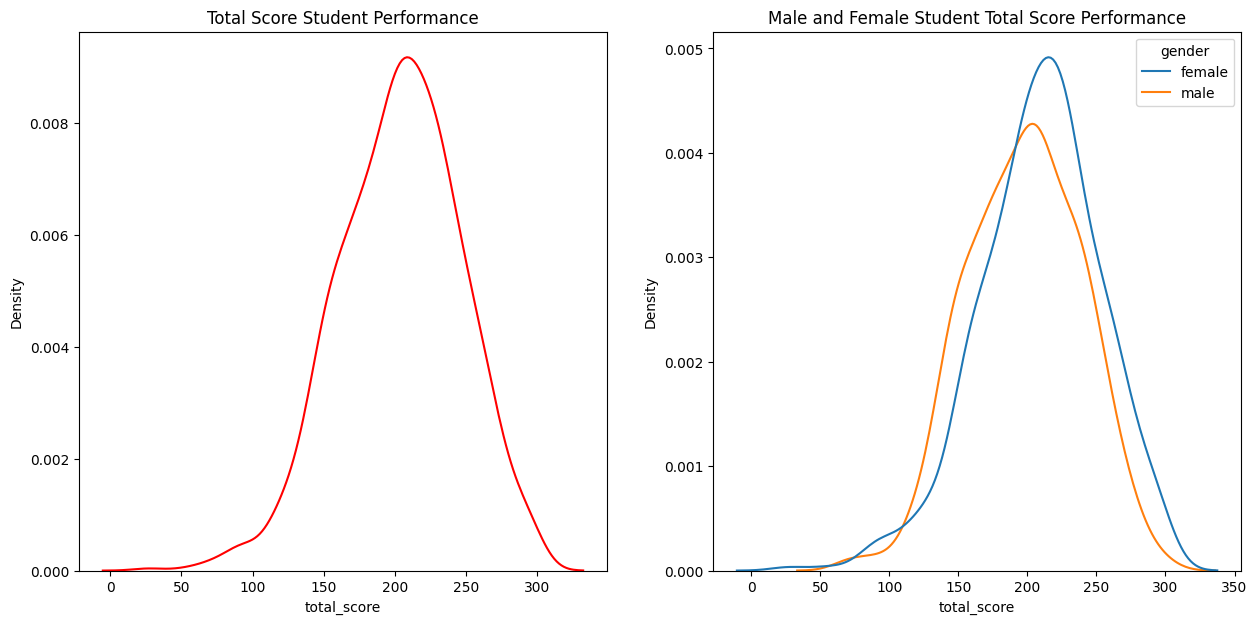

In [59]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.kdeplot(data=df,x='total_score',color='r')
plt.title('Total Score Student Performance')

plt.subplot(122)
sns.kdeplot(data=df,x='total_score',hue='gender')
plt.title('Male and Female Student Total Score Performance')
plt.show()

### `Insights`
* w.r.t total score female are performing better. 

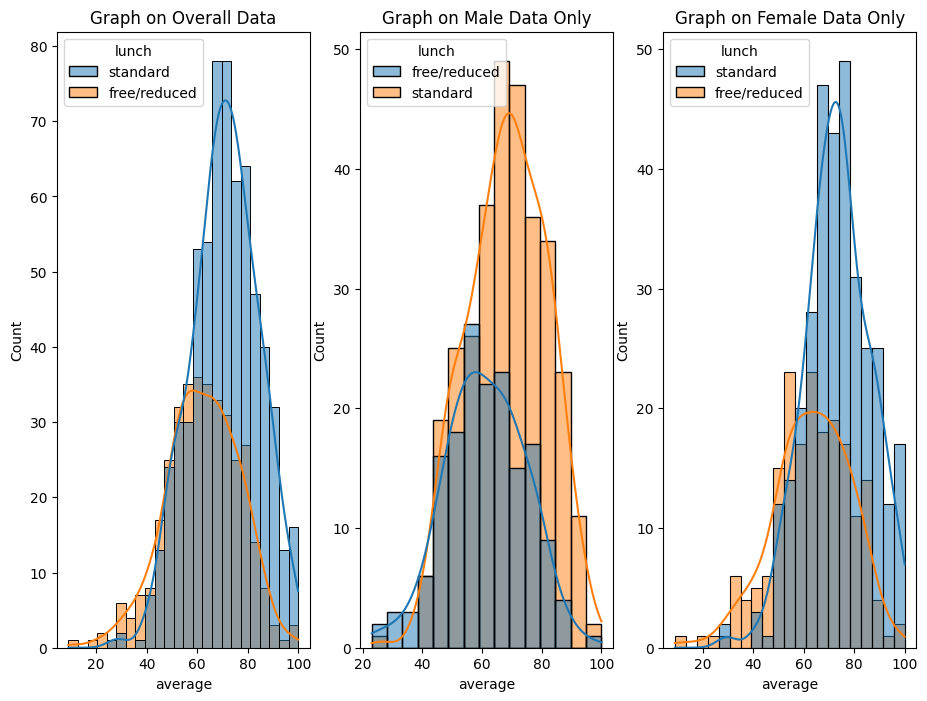

In [76]:
plt.figure(figsize=(15,8))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.title('Graph on Overall Data')
plt.subplot(142)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='lunch')
plt.title('Graph on Male Data Only')
plt.subplot(143)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='lunch')
plt.title('Graph on Female Data Only')
plt.show()

### Insights
* `Standared lunch helps perform well in exams.`
* `No matter some one is male or female Standard lunch helps to perform better for performing in exam.`


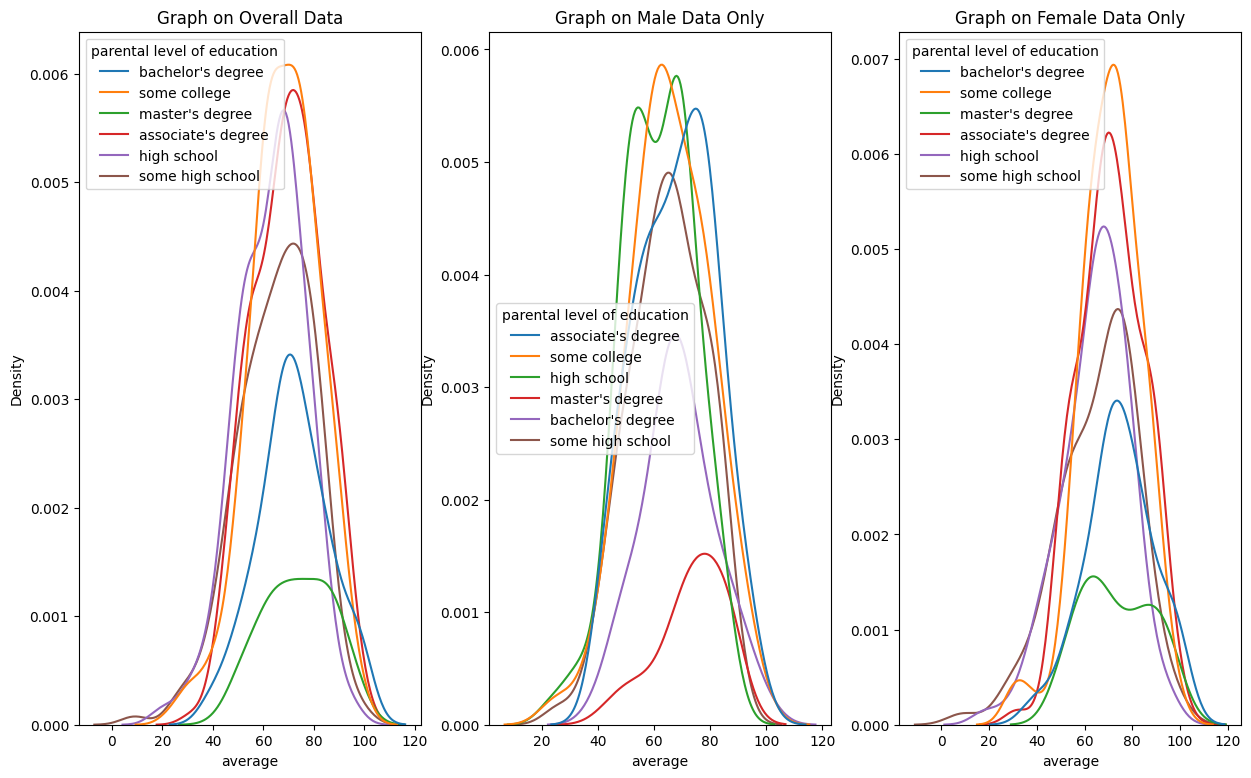

In [75]:
plt.figure(figsize=(15,9))
plt.subplot(131)
sns.kdeplot(data=df,x='average',hue='parental level of education')
plt.title('Graph on Overall Data')
plt.subplot(132)
sns.kdeplot(data=df[df['gender']=='male'],x='average',hue='parental level of education')
plt.title('Graph on Male Data Only')
plt.subplot(133)
sns.kdeplot(data=df[df['gender']=='female'],x='average',hue='parental level of education')
plt.title('Graph on Female Data Only')
plt.show()

## Insights
* Ingeneral parent's education not help student to perform well in exam.
* But parent whose educaiton is of associate degree or Master Degree their male child performing better in exam


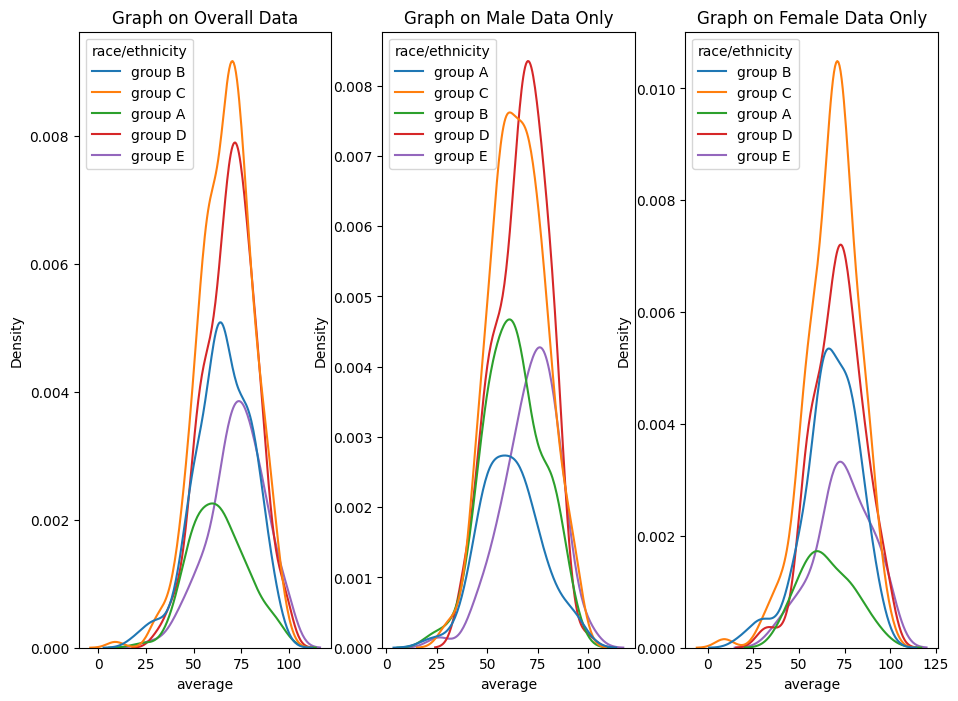

In [82]:
plt.figure(figsize=(15,8))
plt.subplot(141)
sns.kdeplot(data=df,x='average',hue='race/ethnicity')
plt.title('Graph on Overall Data')
plt.subplot(142)
sns.kdeplot(data=df[df['gender']=='male'],x='average',hue='race/ethnicity')
plt.title('Graph on Male Data Only')
plt.subplot(143)
sns.kdeplot(data=df[df['gender']=='female'],x='average',hue='race/ethnicity')
plt.title('Graph on Female Data Only')
plt.show()

### Insights
* Student of Group A and Group D tends to perform poorly in exam. 
* Students of Group A and Group B tends to perform poorly irrespective of whether they are male or female.

## 4.2 Maximumum score of students in all three subjects

In [84]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total_score', 'average'],
      dtype='object')

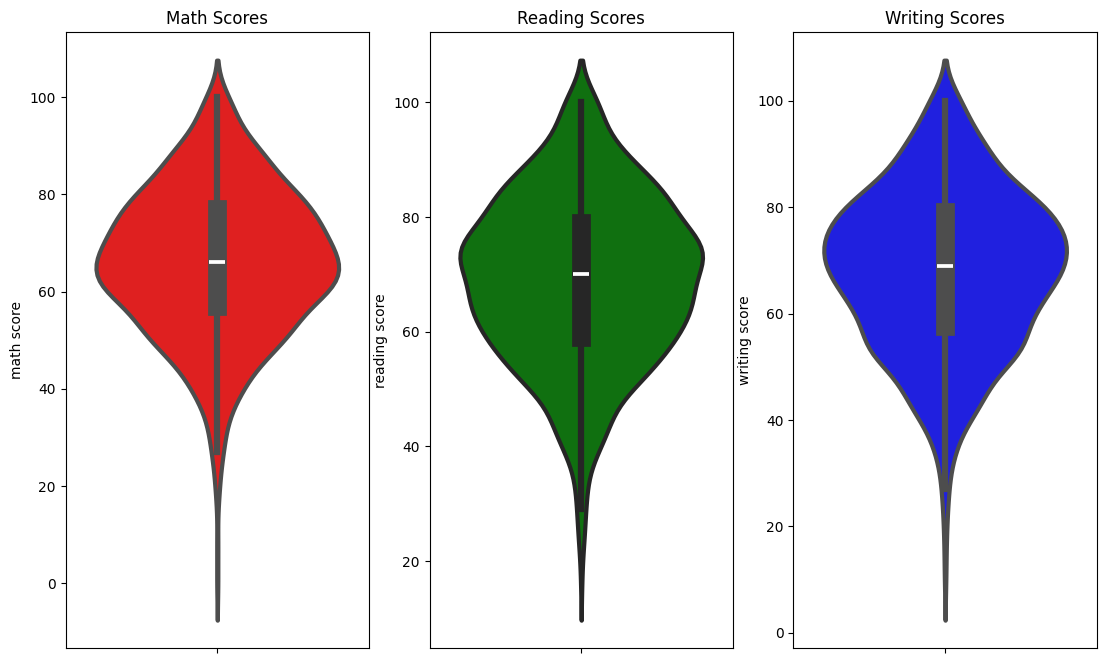

In [90]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Math Scores')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Scores')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1,4,3)
plt.title('Writing Scores')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

# Insights
* From the above three plots its clearly visible that most of the students score in between `60-80 in Maths`
* whereas in reading and writing most of them score from` 50-80`

# 4.3 Multivariate analysis using pieplot

(-1.25, 1.25, -1.25, 1.25)

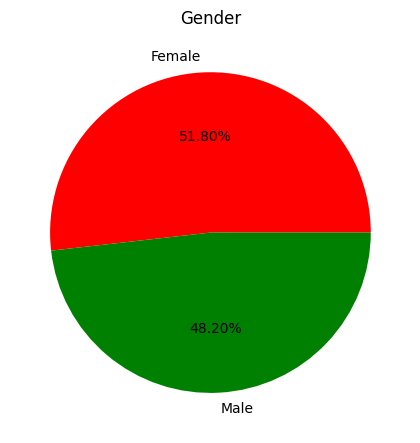

In [99]:

# plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '%.2f%%')
plt.title('Gender')
plt.axis('off')




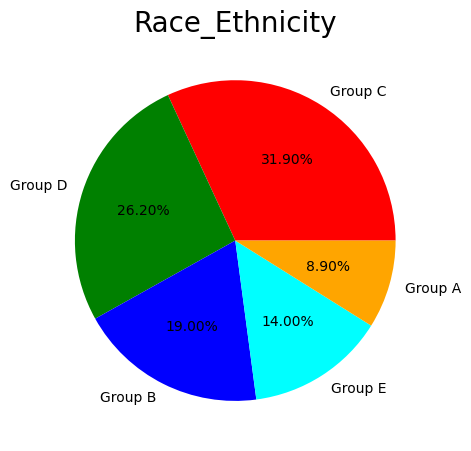

In [102]:

plt.subplot(1, 5, 1)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')

plt.show()

(-1.25, 1.25, -1.25, 1.25)

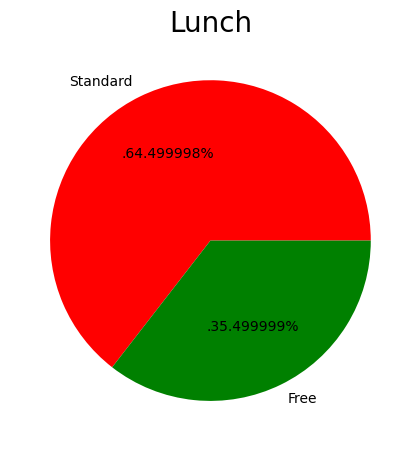

In [103]:
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

(-1.25, 1.25, -1.25, 1.25)

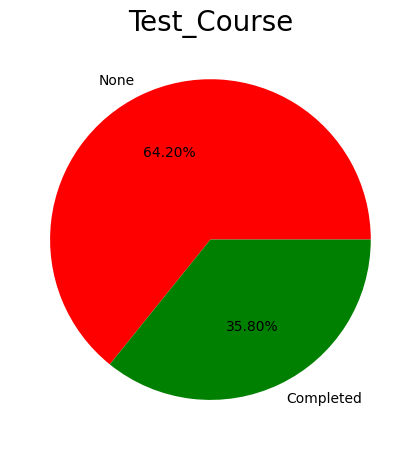

In [111]:
plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Test_Course', fontsize = 20)
plt.axis('off')

(-1.25, 1.25, -1.25, 1.25)

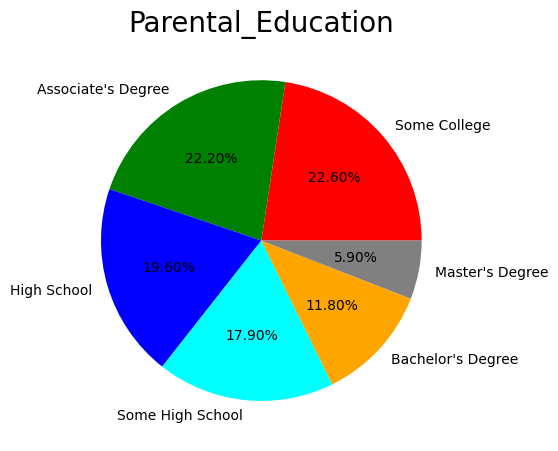

In [112]:
plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Parental_Education', fontsize = 20)
plt.axis('off')

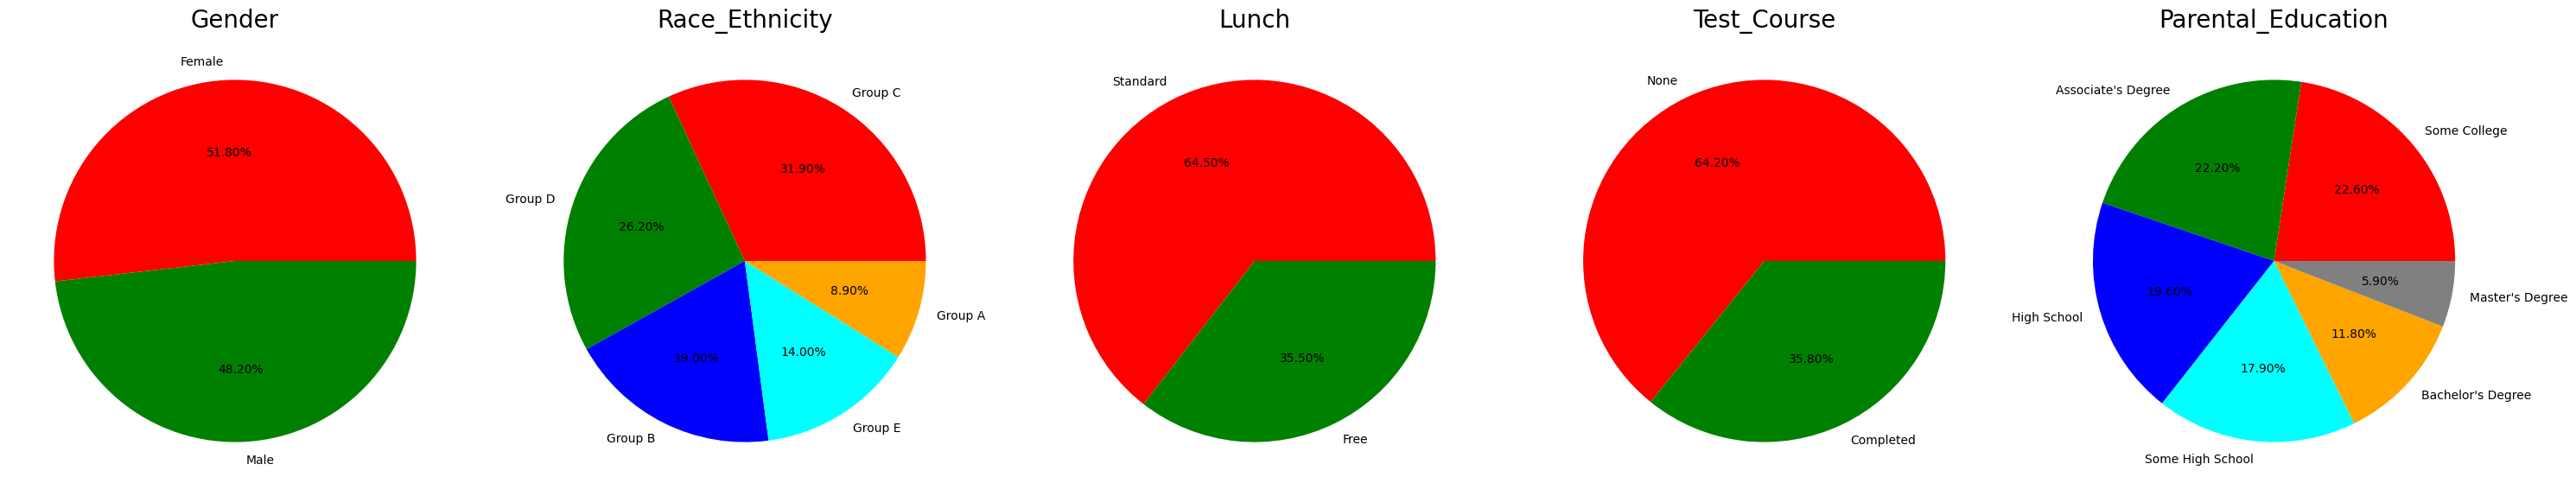

In [110]:
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Test_Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '%.2f%%')
plt.title('Parental_Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()


# 4.4 Feature Wise Visualization
## 4.4.1 GENDER COLUMN
* How is distribution of Gender ?

* Is gender has any impact on student's performance ?
`UNIVARIATE ANALYSIS ( How is distribution of Gender ? )`

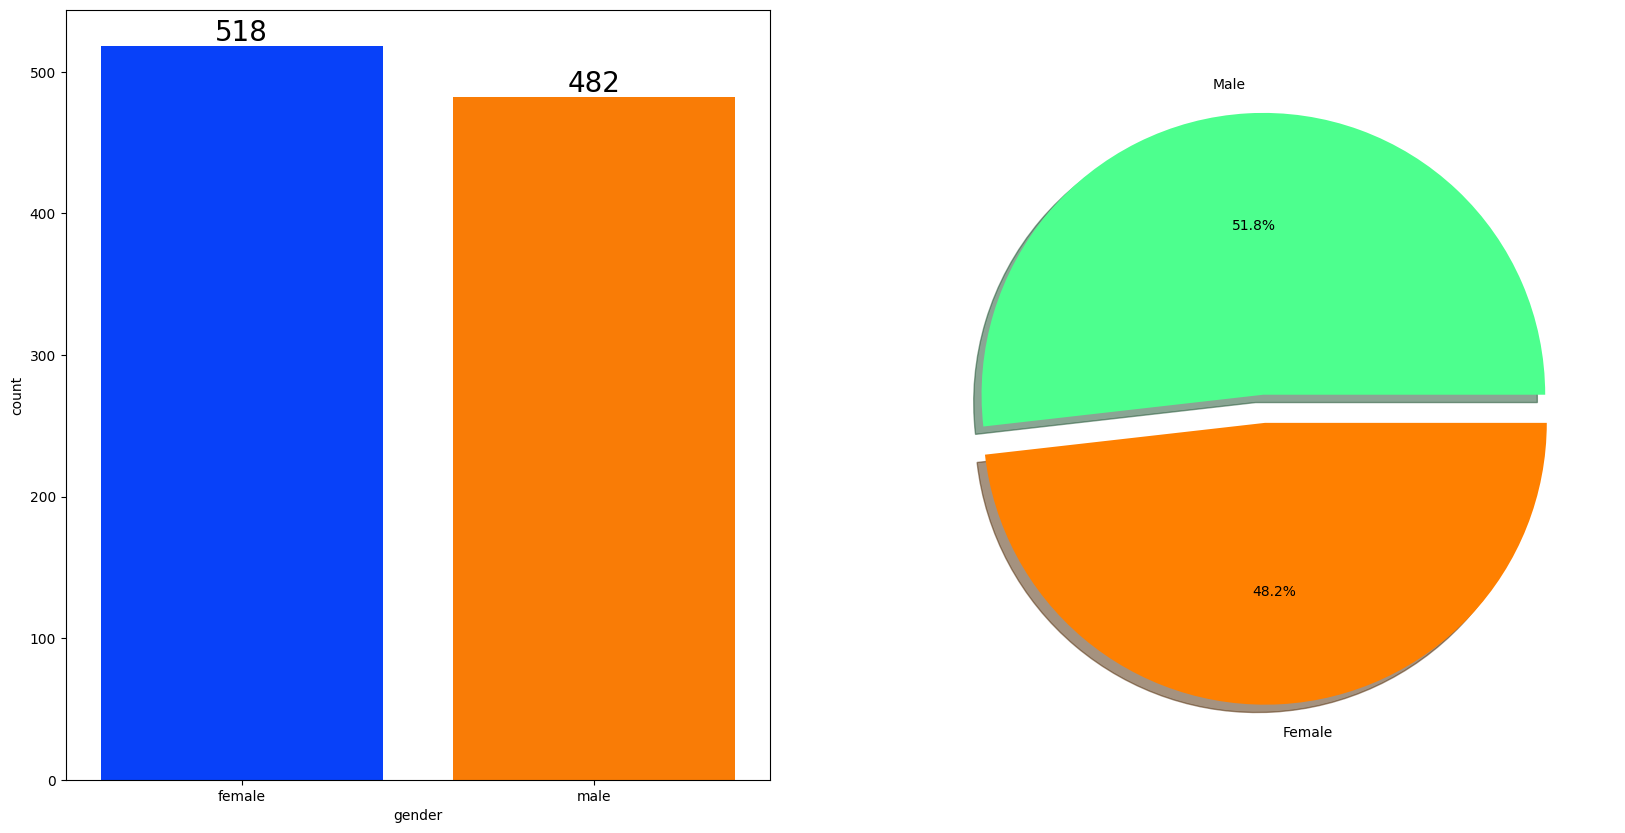

In [120]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=["#4dff8e",'#ff8000'])
plt.show()

# Insights
* Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [132]:
gender_group = df.groupby('gender')[['math score',	'reading score','writing score','total_score','average']].mean()
gender_group

,math score,reading score,writing score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


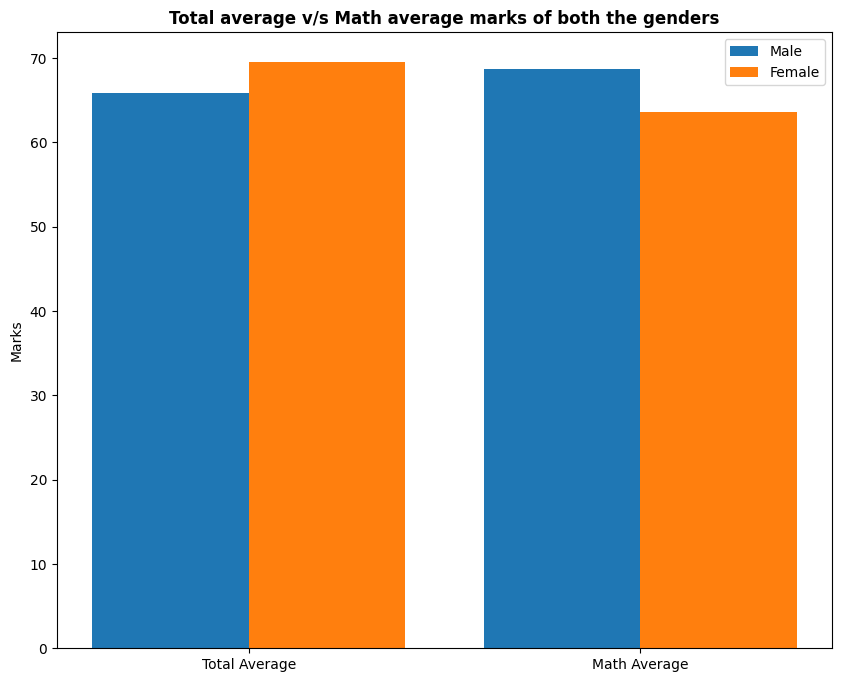

In [144]:
plt.figure(figsize=(10, 8))
X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

# Insights
* On an average females have a better overall score than men.
*  whereas males have scored higher in Maths.

## 4.4.2 RACE/EHNICITY COLUMN
#### -> How is Group wise distribution ?
#### -> Is Race/Ehnicity has any impact on student's performance ?

UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

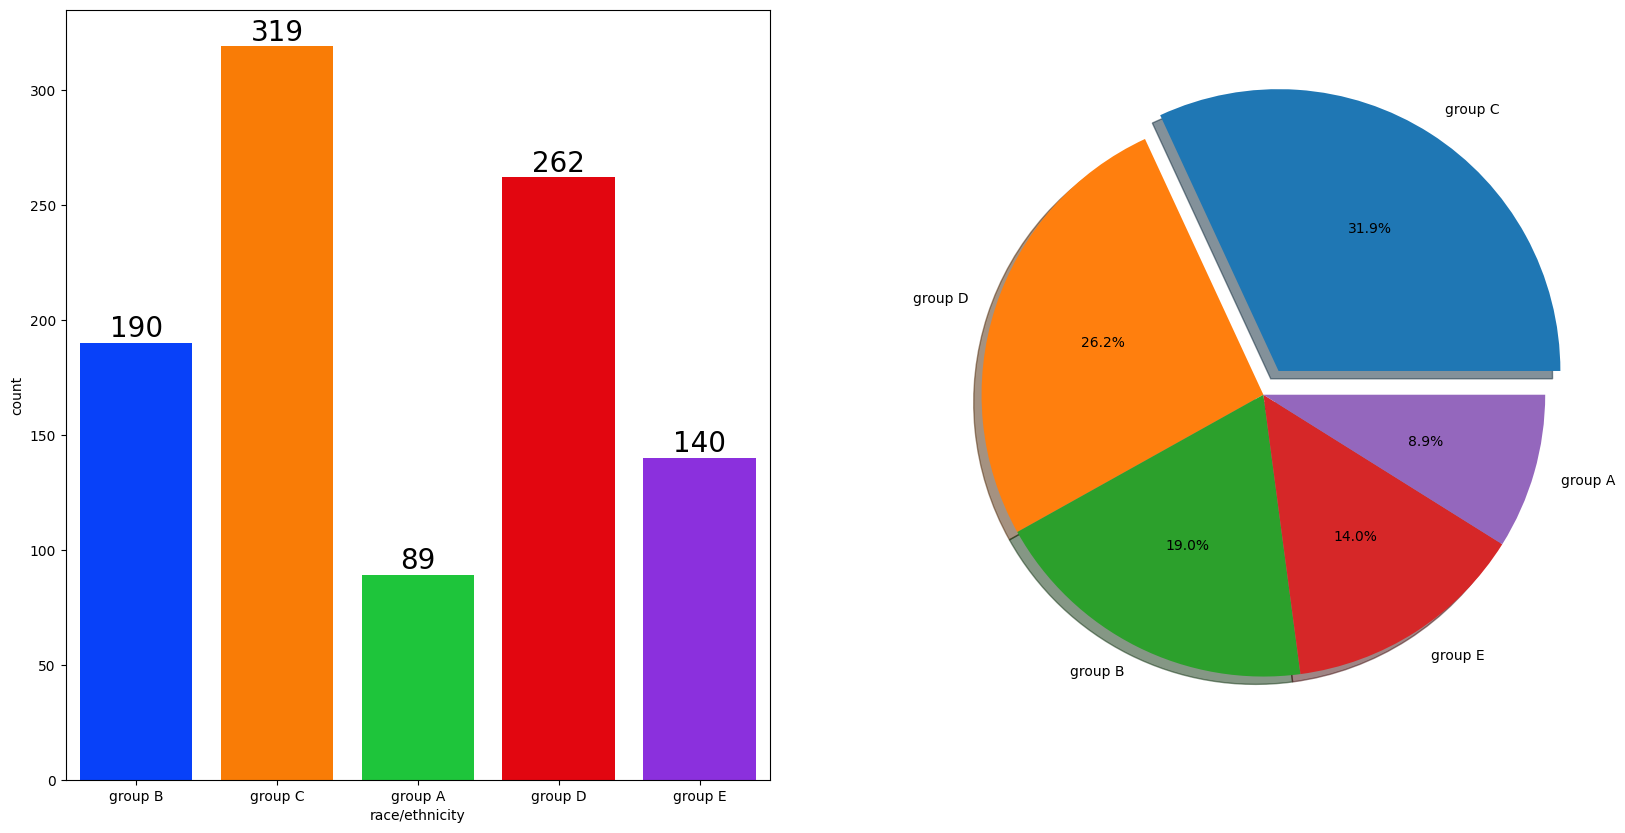

In [147]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

# Insights
* Most of the student belonging from group C /group D.
* Lowest number of students belong to groupA.

# BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

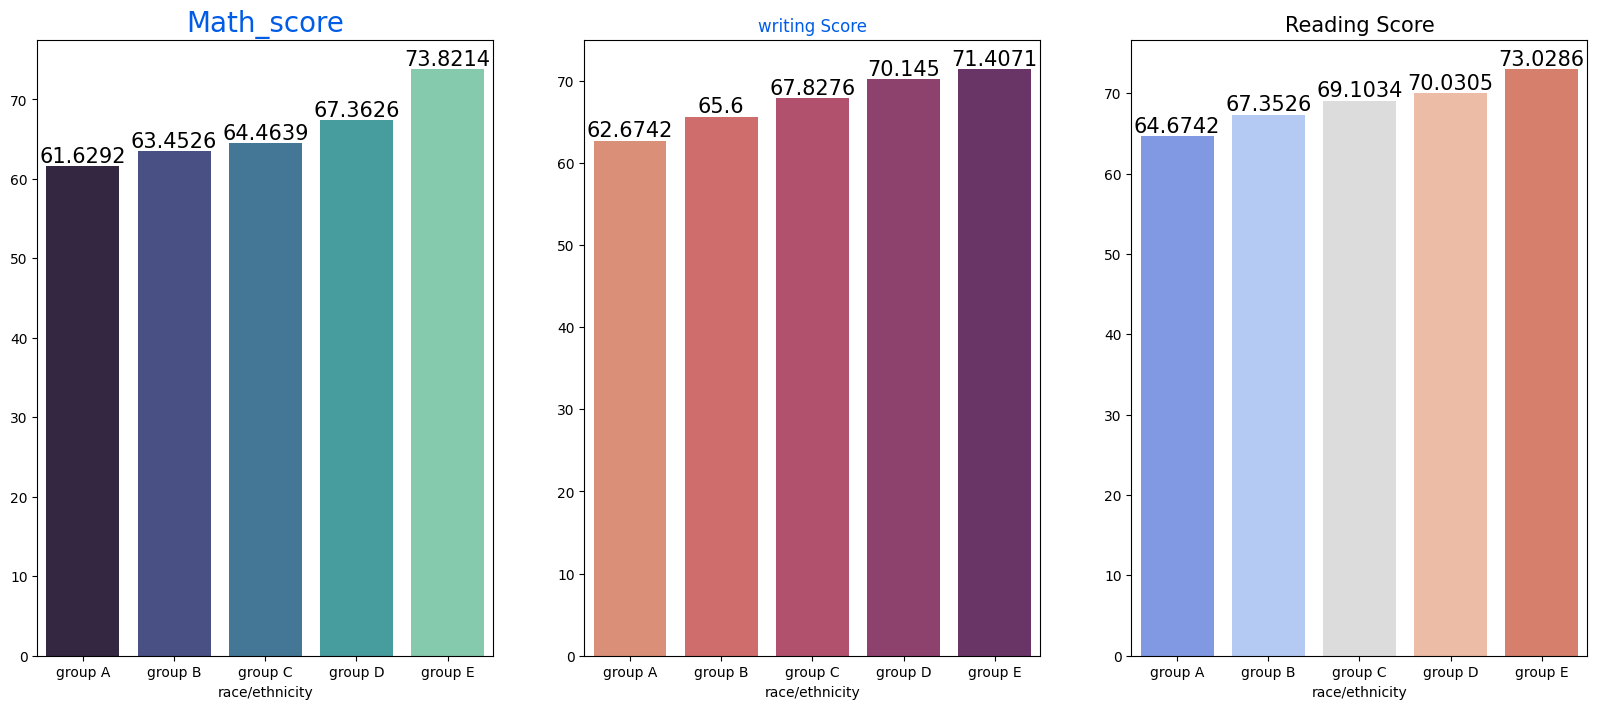

In [178]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math_score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)
    

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('writing Score',color='#005ce6')

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)
    
    
sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Reading Score',color='black',size=15)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

# Insights
* Group E students have scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all course subjects

# 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
* What is educational background of student's parent ?

* Is parental education has any impact on student's performance ?

### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

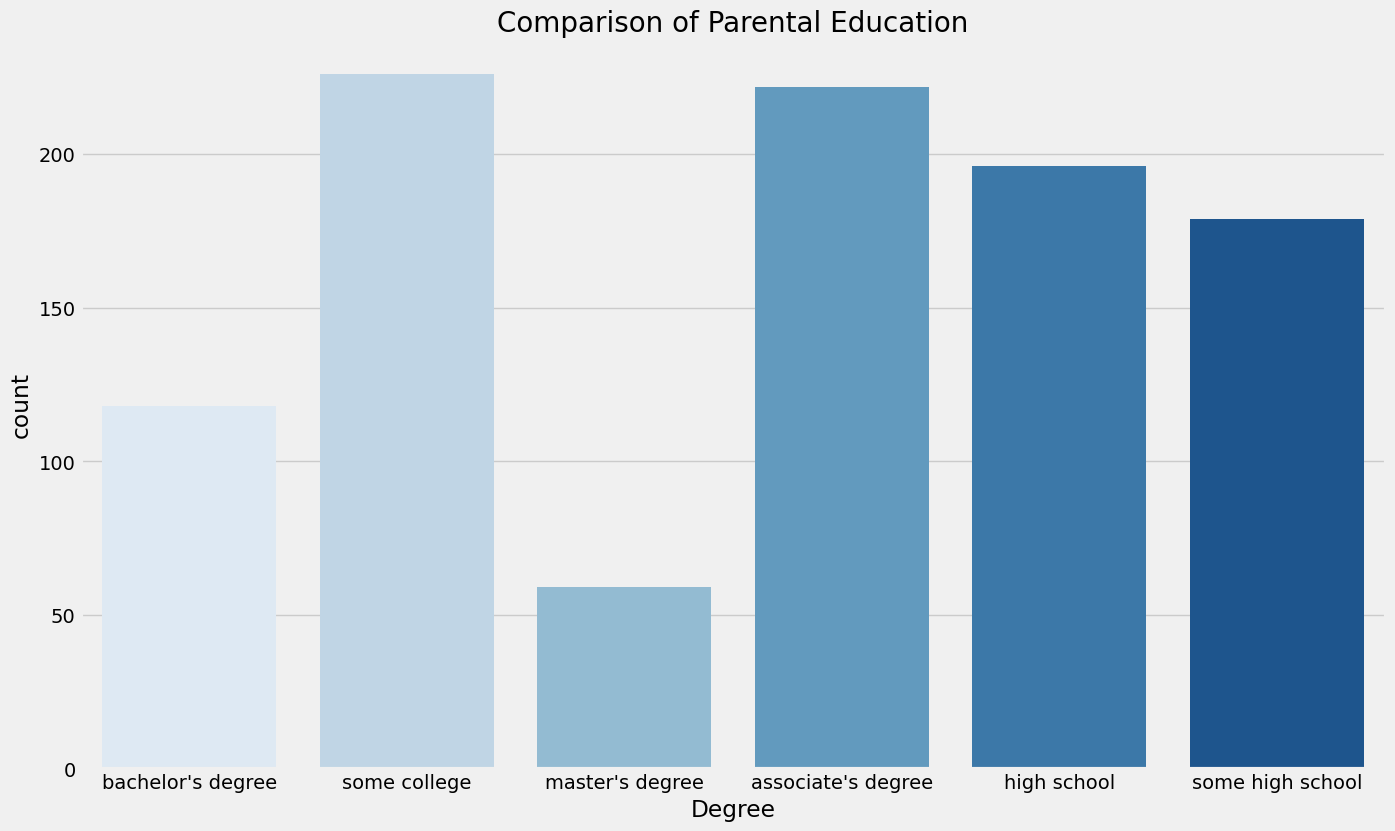

In [180]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(x = df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

### Insights
* Largest number of parents are from some college.

<Axes: >

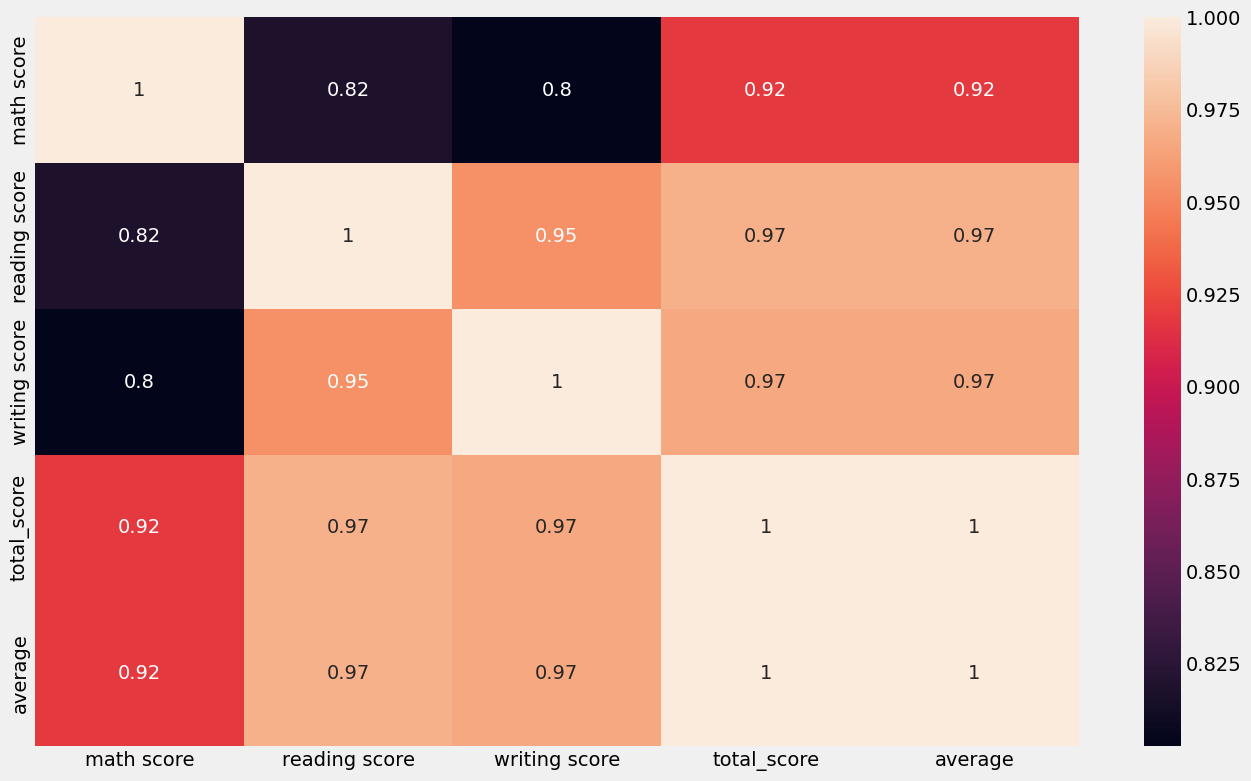

In [185]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

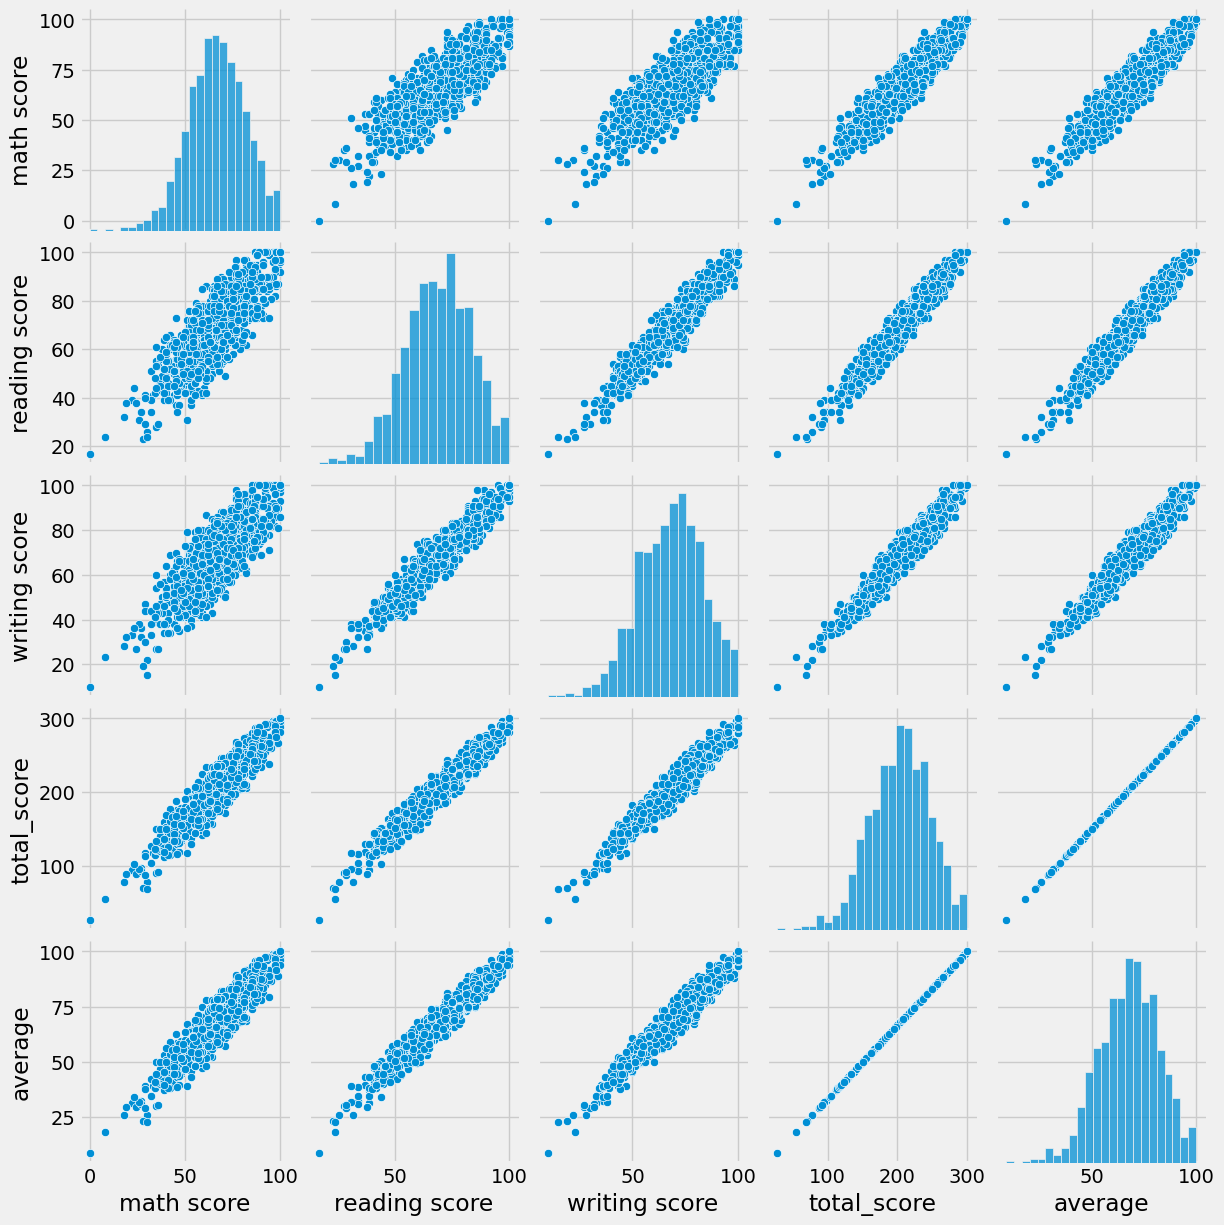

In [186]:
sns.pairplot(df)

### BIVARIATE ANALYSIS (Is parental education has any impact on student's performance?)

In [200]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total_score', 'average'],
      dtype='object')

In [203]:
grouped_data = df.groupby('parental level of education')[['math score','reading score','writing score','total_score','average']].mean()

In [211]:
grouped_data = grouped_data.reset_index()

In [212]:
grouped_data

,parental level of education,math score,reading score,writing score,total_score,average
0,associate's degree,67.882883,70.927928,69.896396,208.707207,69.569069
1,bachelor's degree,69.389831,73.000000,73.381356,215.771186,71.923729
2,high school,62.137755,64.704082,62.448980,189.290816,63.096939
3,master's degree,69.745763,75.372881,75.677966,220.796610,73.598870
4,some college,67.128319,69.460177,68.840708,205.429204,68.476401
5,some high school,63.497207,66.938547,64.888268,195.324022,65.108007


<Axes: xlabel='parental level of education', ylabel='math score'>

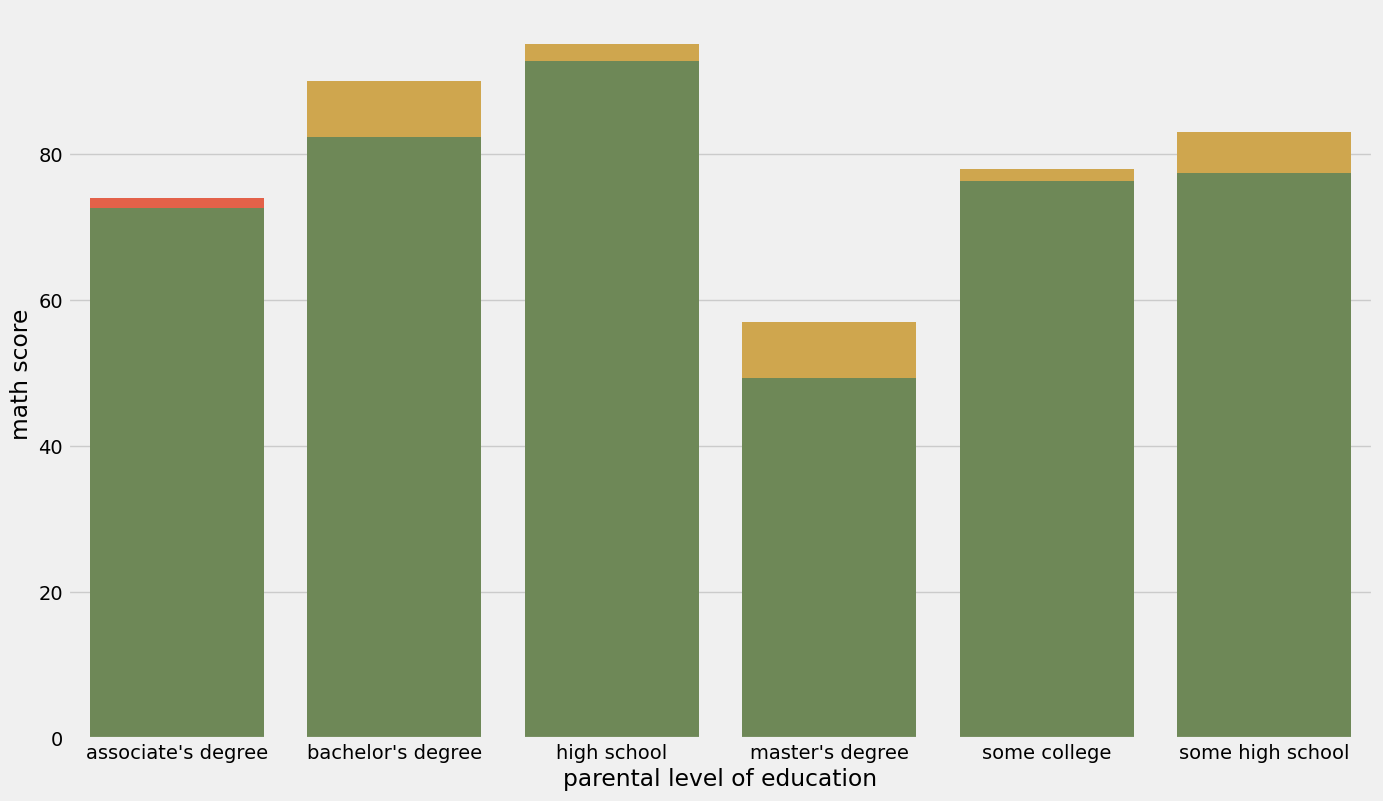

In [215]:
sns.barplot(x = grouped_data['parental level of education'],y ='math score',data=df )
sns.barplot(x = grouped_data['parental level of education'],y ='writing score',data=df )
sns.barplot(x = grouped_data['parental level of education'],y ='reading score',data=df )
sns.barplot(x = grouped_data['parental level of education'],y ='average',data=df )

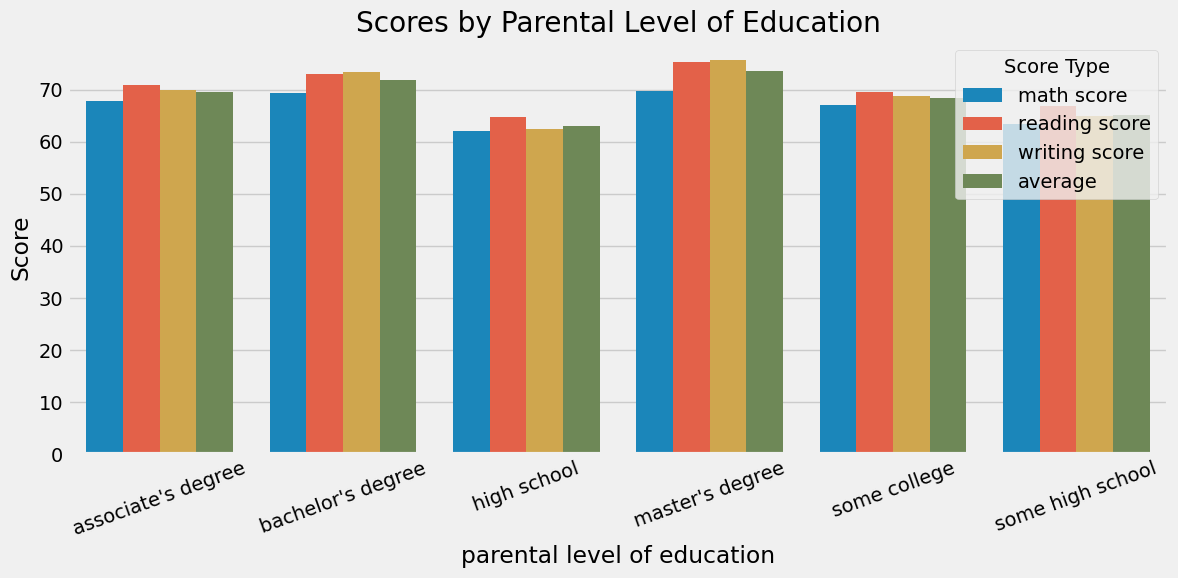

In [217]:
# Convert wide format to long format
plot_data = grouped_data.melt(
    id_vars='parental level of education',
    value_vars=['math score', 'reading score', 'writing score', 'average'],
    var_name='Score Type',
    value_name='Score'
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_data,
    x='parental level of education',
    y='Score',
    hue='Score Type'
)

plt.xticks(rotation=20)
plt.title('Scores by Parental Level of Education')
plt.tight_layout()
plt.show()

# 4.4.4 LUNCH COLUMN
* Which type of lunch is most common amoung students ?

* What is the effect of lunch type on test results?

### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

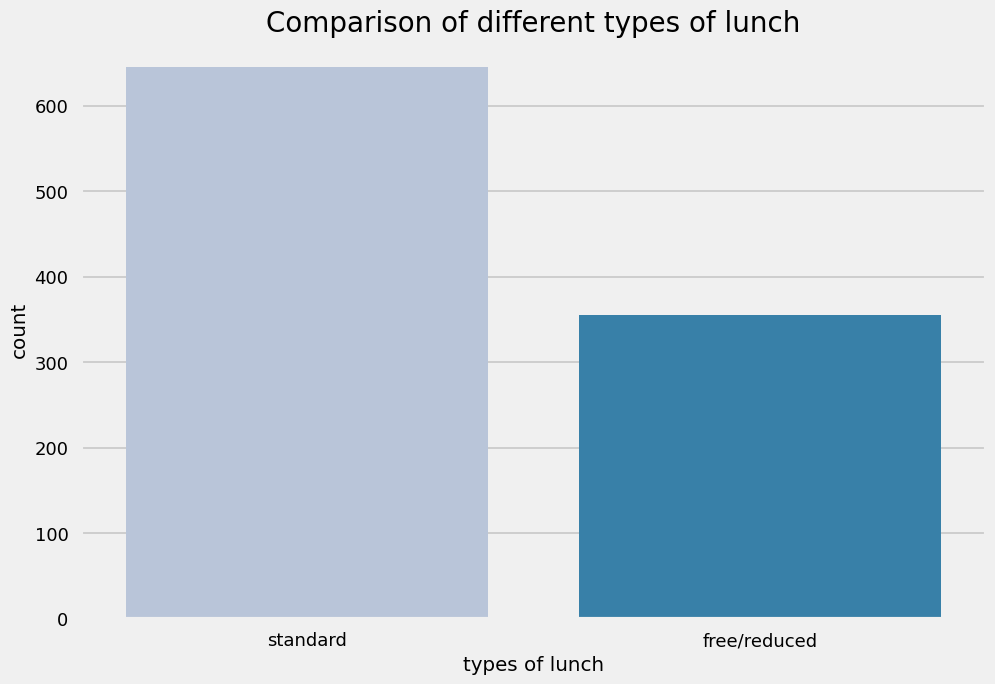

In [218]:

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(x = df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

# Insights
* Students being served Standard lunch was more than free lunch


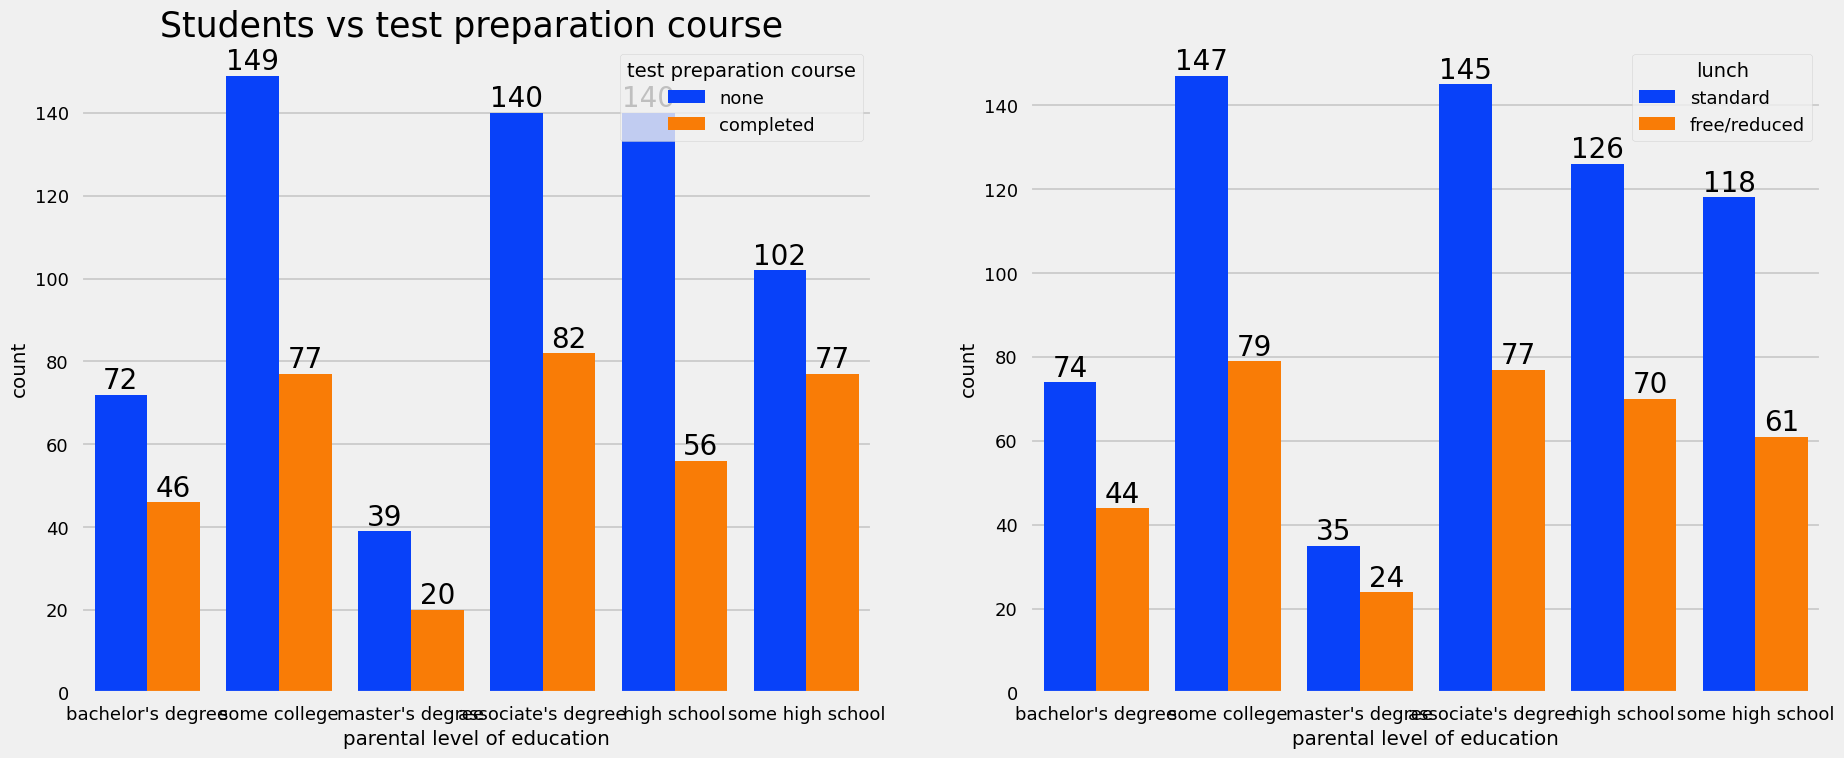

In [223]:

f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    


sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

# 4.4.6 CHECKING OUTLIERS

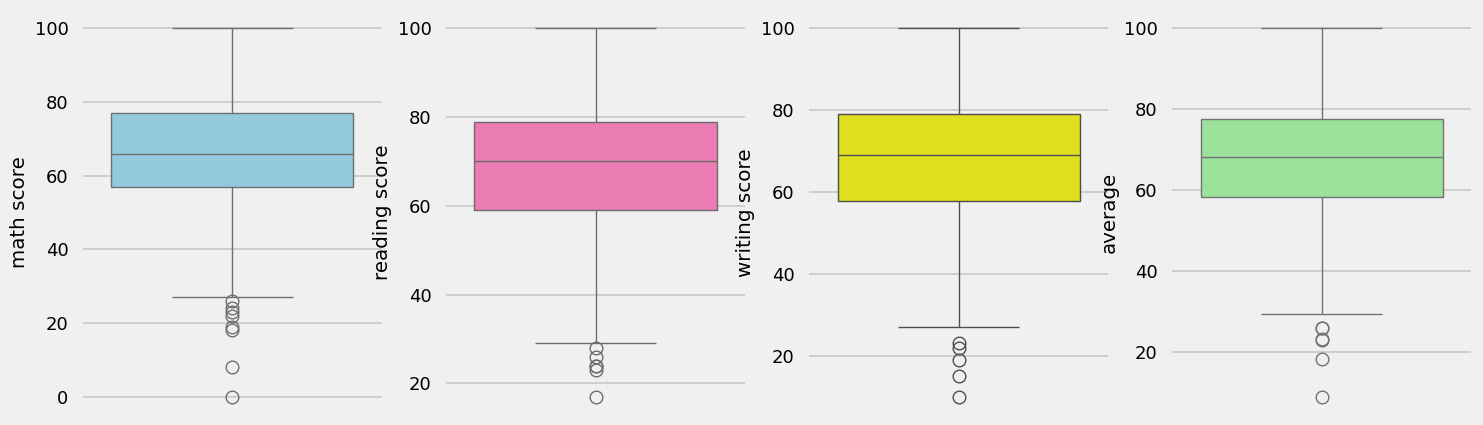

In [224]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()


# 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

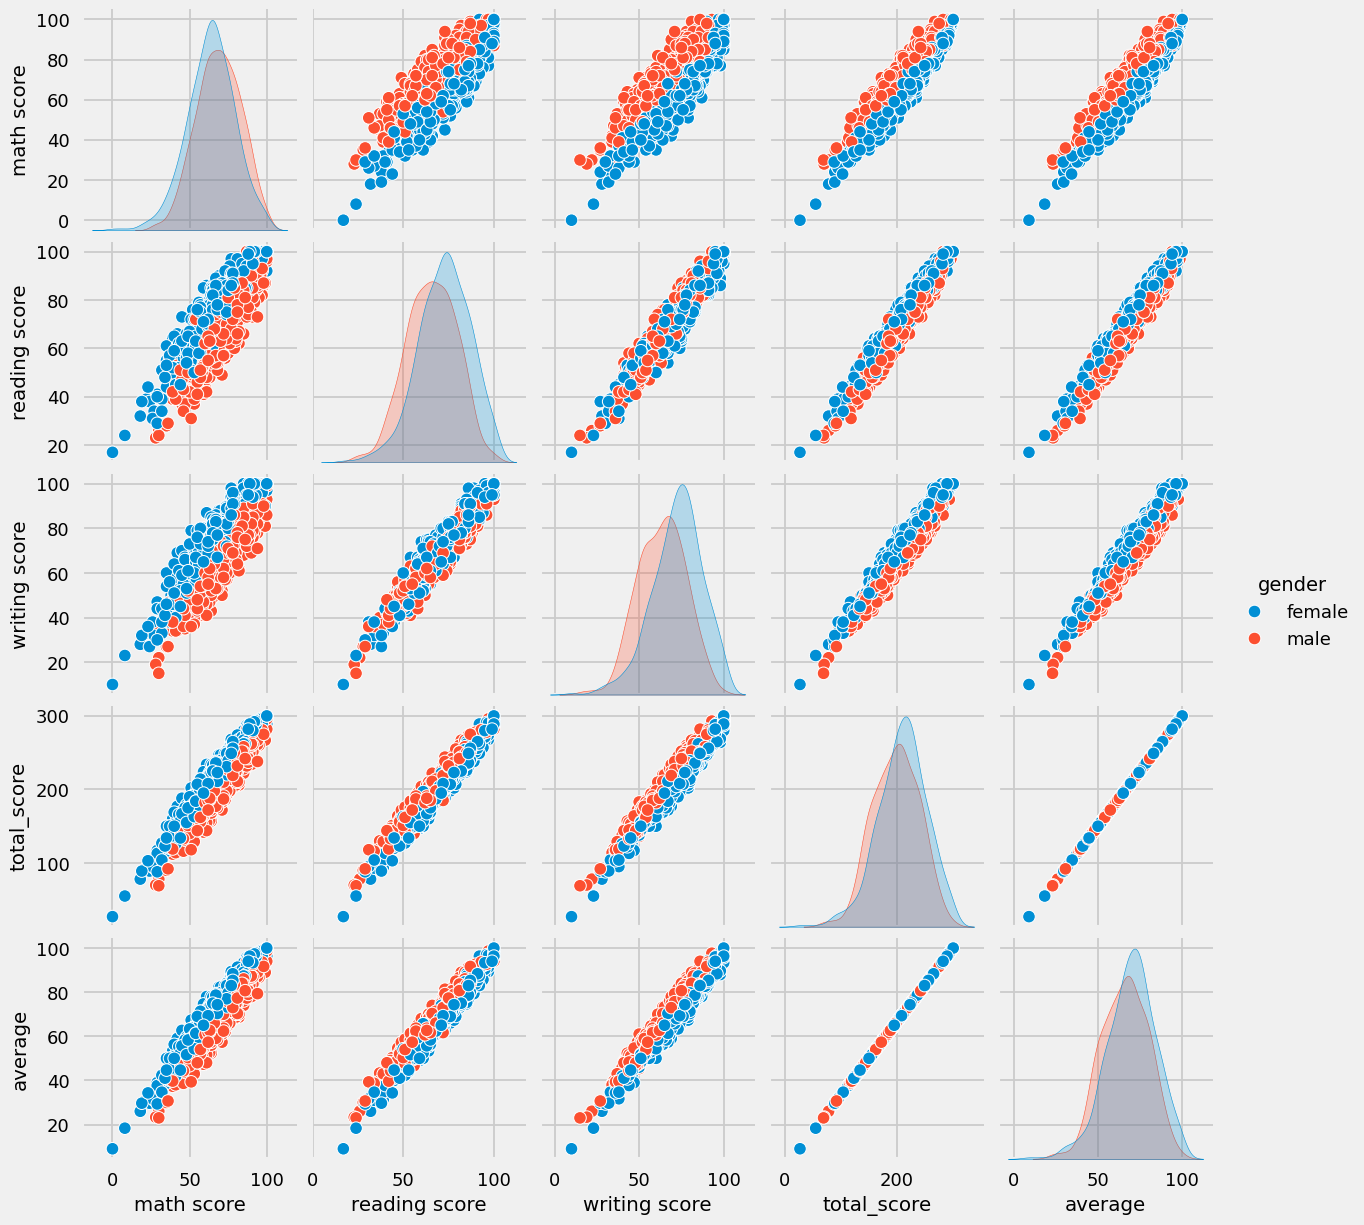

In [225]:
sns.pairplot(df,hue = 'gender')
plt.show()


# Insights
 *  From the above plot it is clear that all the scores increase linearly with each other.


# 5. Conclusions

* Student's Performance is related with lunch, race, parental level education

* Females lead in pass percentage and also are top-scorers

* Student's Performance is not much related with test preparation course

* Finishing preparation course is benefitial.